In [1]:
from ultralytics import YOLO

shelf_model = YOLO("../models/shelf_detection_best.pt")

print(f"Classes: {shelf_model.names}")

Classes: {0: 'object'}


In [2]:
shelf_results = shelf_model.predict(source="../models/test/shelf_test.jpg", save=False, conf=0.25)
result = shelf_results[0]
print(f"Detected {len(result.boxes)} objects")

image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 480x640 114 objects, 80.7ms
Speed: 4.4ms preprocess, 80.7ms inference, 9.2ms postprocess per image at shape (1, 3, 480, 640)
Detected 114 objects


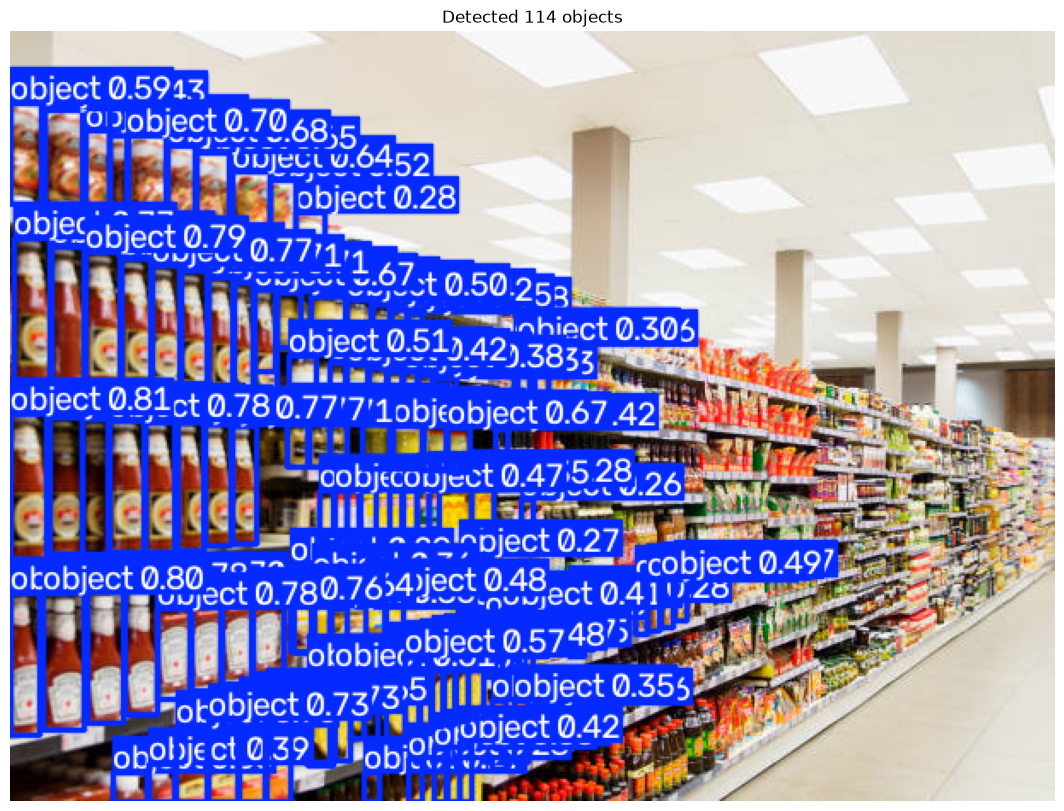

In [3]:
import matplotlib.pyplot as plt

annotated = result.plot()
plt.figure(figsize=(14, 10))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.title(f"Detected {len(result.boxes)} objects")
plt.show()

In [4]:
shelf_results = shelf_model.predict(source="../models/test/shelf_test_empty.jpg", save=False, conf=0.25)
result = shelf_results[0]
print(f"Detected {len(result.boxes)} objects")


image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test_empty.jpg: 544x640 90 objects, 64.4ms
Speed: 2.9ms preprocess, 64.4ms inference, 1.0ms postprocess per image at shape (1, 3, 544, 640)
Detected 90 objects


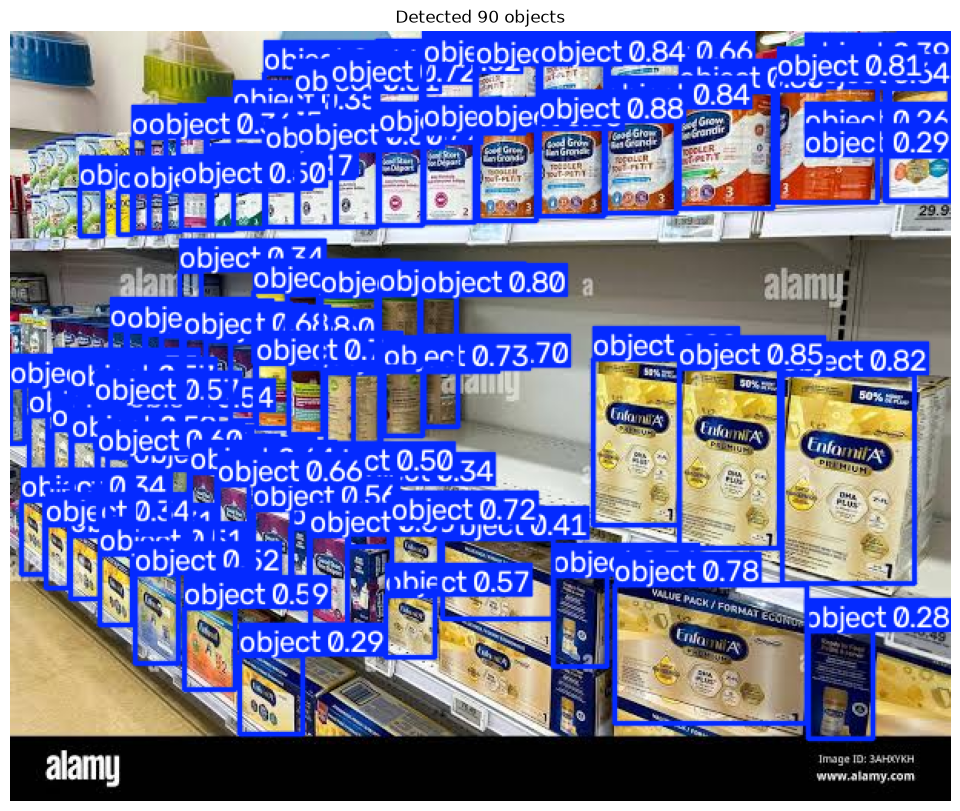

In [5]:
import matplotlib.pyplot as plt

annotated = result.plot()
plt.figure(figsize=(14, 10))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.title(f"Detected {len(result.boxes)} objects")
plt.show()

In [6]:
def analyze_shelf(result) -> dict:
    """Convert raw YOLO detections into a shelf-status summary."""
    boxes = result.boxes
    num_detections = len(boxes)

    img_h, img_w = result.orig_shape
    total_area = img_h * img_w

    covered_area = 0
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        covered_area += (x2 - x1) * (y2 - y1)

    coverage_pct = min((covered_area / total_area) * 100, 100) 

    if coverage_pct >= 60:
        status = "well-stocked"
    elif coverage_pct >= 30:
        status = "moderately stocked"
    else:
        status = "low stock / significant gaps"

    return {
        "num_items_detected": num_detections,
        "coverage_pct": round(coverage_pct, 1),
        "status": status,
    }

shelf_analysis = analyze_shelf(result)
print(shelf_analysis)

{'num_items_detected': 90, 'coverage_pct': 46.3, 'status': 'moderately stocked'}


In [7]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
import os
from dotenv import load_dotenv

load_dotenv()

vision_llm = ChatGroq(api_key=os.getenv("GROQ_API_KEY"), model="openai/gpt-oss-120b")

vision_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are RetailMesh's shelf monitoring assistant. Given shelf analysis data
(item count, estimated coverage percentage, and status), write a short, clear summary
an operations team member could read at a glance. Mention whether restocking may be needed.
Keep it to 1-2 sentences."""),
    ("human", """Shelf analysis:
- Items detected: {num_items_detected}
- Estimated coverage: {coverage_pct}%
- Status: {status}"""),
])

vision_chain = vision_prompt | vision_llm

summary = vision_chain.invoke(shelf_analysis)
print(summary.content)

The shelf holds 90 items, covering roughly 46 % of its space and is classified as moderately stocked. Restocking may be needed soon to maintain optimal levels.


In [8]:
def analyze_shelf_image(image_path: str) -> dict:
    """Full pipeline: run YOLO on a shelf image, compute metrics, generate a natural-language summary."""
    results = shelf_model.predict(source=image_path, save=False, conf=0.25)
    result = results[0]

    metrics = analyze_shelf(result)
    summary = vision_chain.invoke(metrics)

    return {
        "image_path": image_path,
        "metrics": metrics,
        "summary": summary.content,
    }

output = analyze_shelf_image("../models/test/shelf_test.jpg") 
print(output["summary"])
print(output["metrics"])


image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 480x640 114 objects, 31.3ms
Speed: 1.9ms preprocess, 31.3ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)
The shelf shows only 114 items covering about 24.8% of the space, indicating low stock with significant gaps—restocking is recommended promptly.
{'num_items_detected': 114, 'coverage_pct': 24.8, 'status': 'low stock / significant gaps'}



image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 960x1280 231 objects, 99.4ms
Speed: 6.4ms preprocess, 99.4ms inference, 1.1ms postprocess per image at shape (1, 3, 960, 1280)
Detected 231 objects at imgsz=1280 (vs 90 at 640)


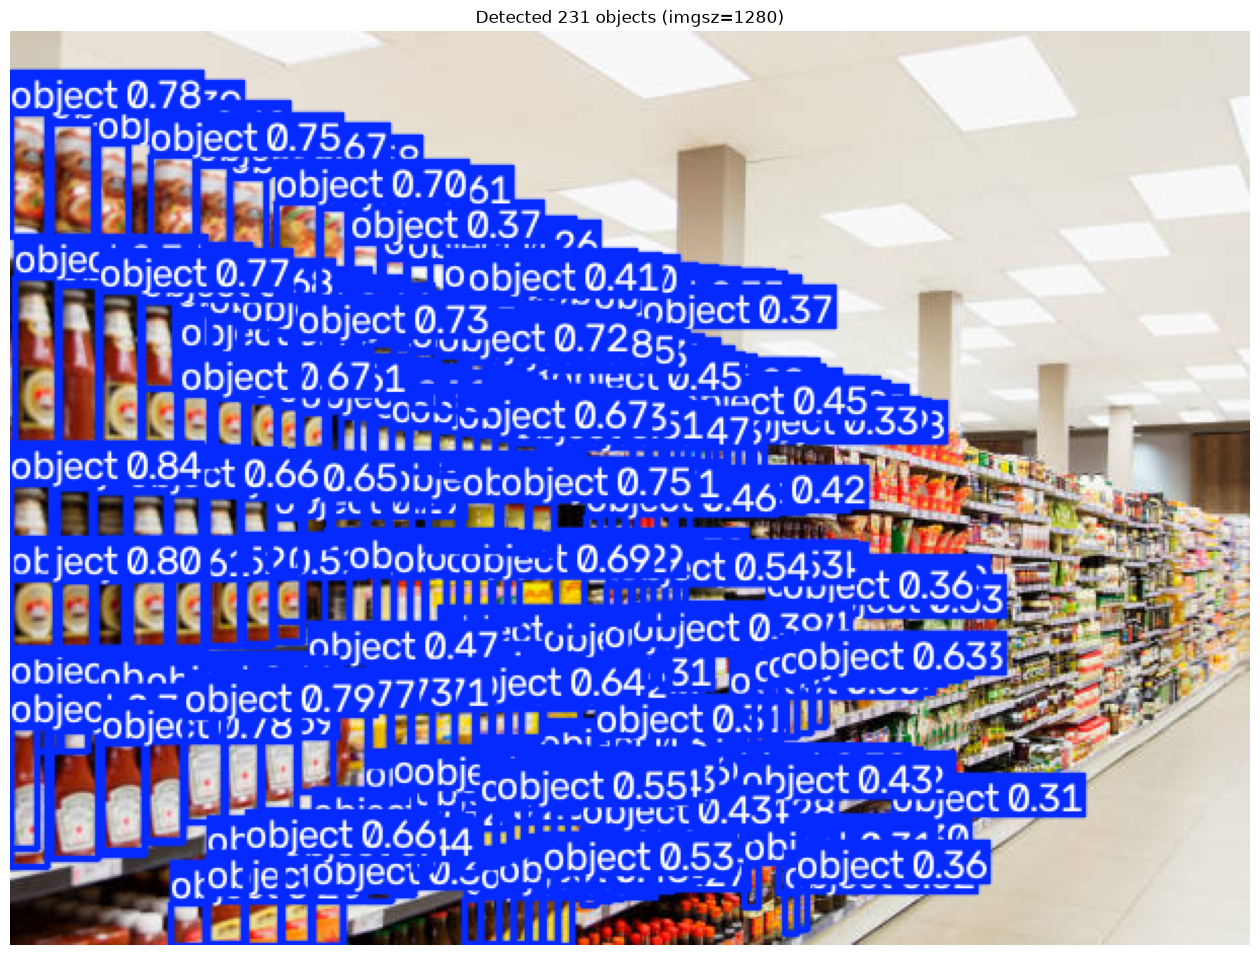

In [9]:
shelf_results_hires = shelf_model.predict(
    source="../models/test/shelf_test.jpg",
    save=False,
    conf=0.25,
    imgsz=1280,  # up from the default 640
)
result_hires = shelf_results_hires[0]
print(f"Detected {len(result_hires.boxes)} objects at imgsz=1280 (vs {len(result.boxes)} at 640)")

annotated_hires = result_hires.plot()
plt.figure(figsize=(16, 12))
plt.imshow(annotated_hires[..., ::-1])
plt.axis("off")
plt.title(f"Detected {len(result_hires.boxes)} objects (imgsz=1280)")
plt.show()

In [10]:
shelf_results_lowconf = shelf_model.predict(
    source="../models/test/shelf_test.jpg",
    save=False,
    conf=0.05,  # much lower — diagnostic only, not a real operating threshold
    imgsz=640,
)
print(f"Detected {len(shelf_results_lowconf[0].boxes)} objects at conf=0.05 (vs {len(result.boxes)} at conf=0.25)")


image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 480x640 300 objects, 45.0ms
Speed: 1.6ms preprocess, 45.0ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Detected 300 objects at conf=0.05 (vs 90 at conf=0.25)



image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 960x1280 300 objects, 90.9ms
Speed: 6.8ms preprocess, 90.9ms inference, 2.1ms postprocess per image at shape (1, 3, 960, 1280)
Detected 300 objects (imgsz=1280, conf=0.15)


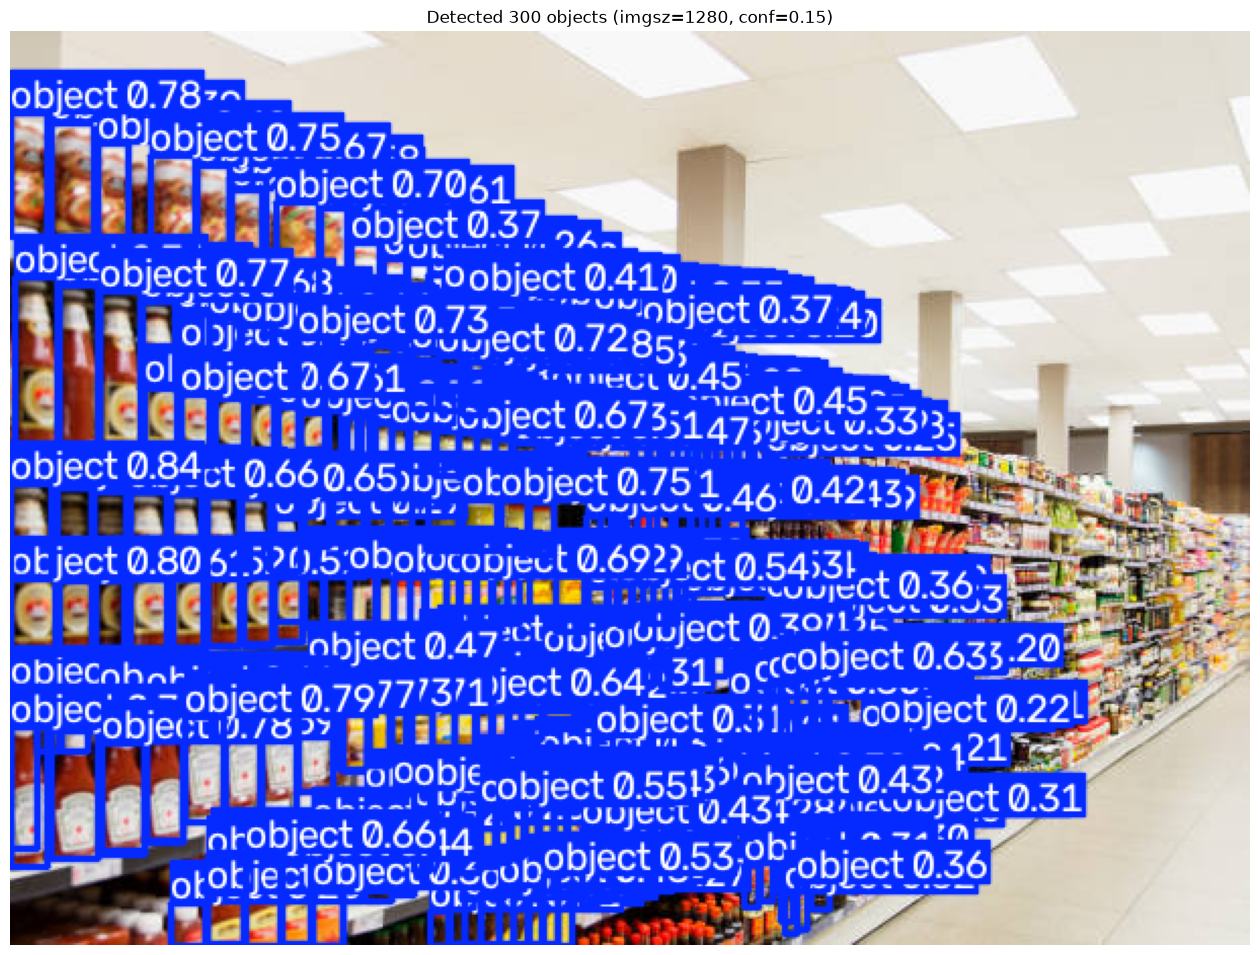

In [11]:
shelf_results_final = shelf_model.predict(
    source="../models/test/shelf_test.jpg",
    save=False,
    conf=0.15,   # middle ground — catches real detections without flooding on noise
    imgsz=1280,
)
result_final = shelf_results_final[0]
print(f"Detected {len(result_final.boxes)} objects (imgsz=1280, conf=0.15)")

annotated_final = result_final.plot()
plt.figure(figsize=(16, 12))
plt.imshow(annotated_final[..., ::-1])
plt.axis("off")
plt.title(f"Detected {len(result_final.boxes)} objects (imgsz=1280, conf=0.15)")
plt.show()


image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 960x1280 300 objects, 114.8ms
Speed: 8.4ms preprocess, 114.8ms inference, 1.9ms postprocess per image at shape (1, 3, 960, 1280)
Detected 300 objects (iou=0.5, vs 300 at default iou=0.7)


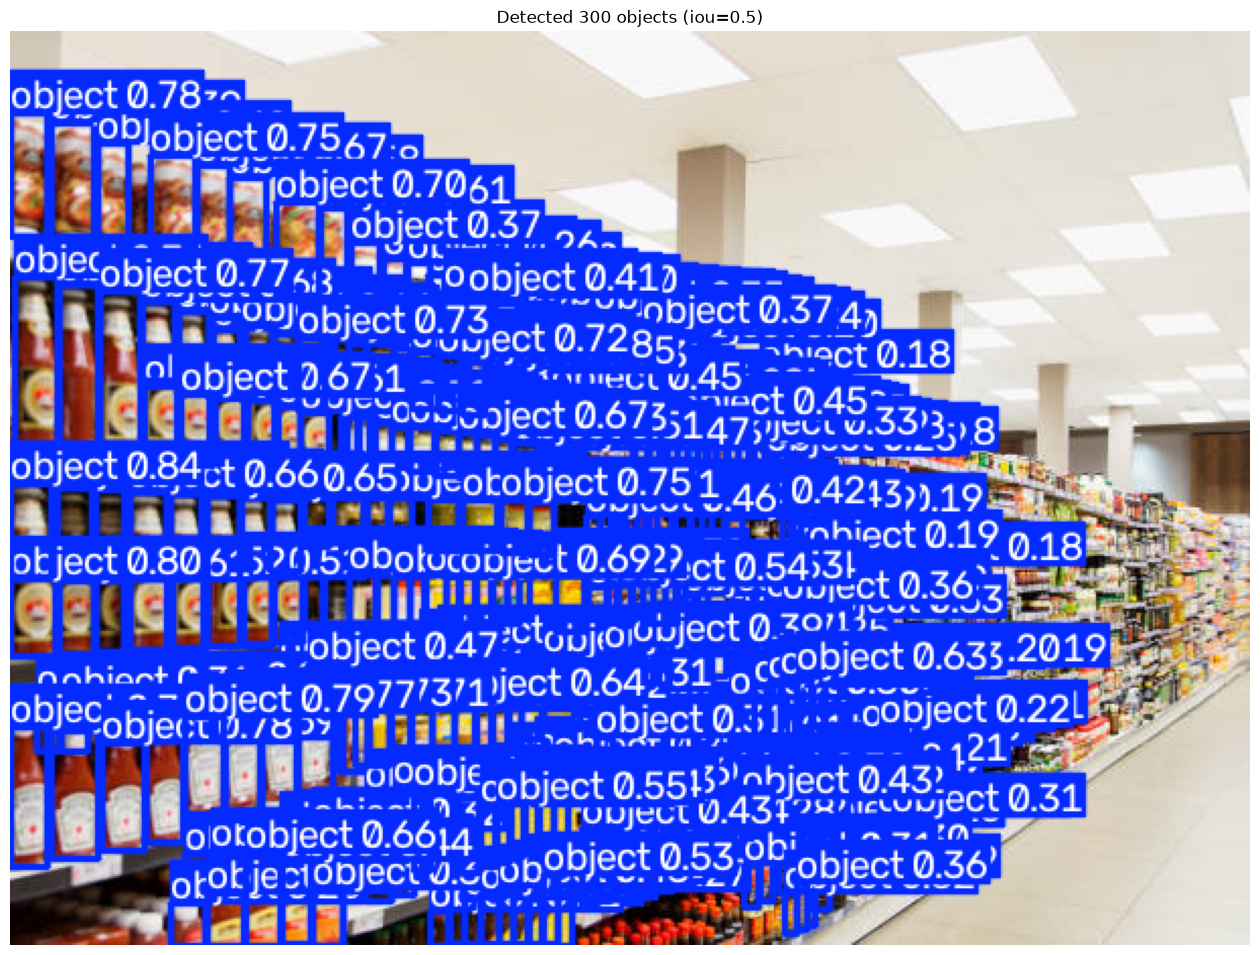

In [12]:
shelf_results_iou = shelf_model.predict(
    source="../models/test/shelf_test.jpg",
    save=False,
    conf=0.15,
    imgsz=1280,
    iou=0.5,  # default is 0.7 — lower means more aggressive duplicate suppression
)
result_iou = shelf_results_iou[0]
print(f"Detected {len(result_iou.boxes)} objects (iou=0.5, vs 300 at default iou=0.7)")

annotated_iou = result_iou.plot()
plt.figure(figsize=(16, 12))
plt.imshow(annotated_iou[..., ::-1])
plt.axis("off")
plt.title(f"Detected {len(result_iou.boxes)} objects (iou=0.5)")
plt.show()

In [13]:
CALIBRATED_CONF = 0.15
CALIBRATED_IMGSZ = 1280
CALIBRATED_IOU = 0.5  # tighter NMS to reduce duplicate/overlapping boxes

shelf_results = shelf_model.predict(
    source="../models/test/shelf_test.jpg",
    save=False,
    conf=CALIBRATED_CONF,
    imgsz=CALIBRATED_IMGSZ,
    iou=CALIBRATED_IOU,
)
result = shelf_results[0]
print(f"Detected {len(result.boxes)} objects (calibrated settings)")


image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 960x1280 300 objects, 114.5ms
Speed: 10.2ms preprocess, 114.5ms inference, 1.8ms postprocess per image at shape (1, 3, 960, 1280)
Detected 300 objects (calibrated settings)


In [14]:
def analyze_shelf(result) -> dict:
    """Convert raw YOLO detections into a shelf-status summary.

    Uses item count rather than area-coverage percentage — coverage-by-area
    is unreliable for wide-angle shots. Thresholds are calibrated empirically
    against test images, not derived analytically.

    Known limitation: distant/small objects in wide-angle shots are
    undercounted due to limited training epochs and base resolution —
    documented in README, addressable with further training if pursued later.
    """
    num_detections = len(result.boxes)

    if num_detections >= 150:
        status = "well-stocked"
    elif num_detections >= 60:
        status = "moderately stocked"
    else:
        status = "low stock / significant gaps"

    return {
        "num_items_detected": num_detections,
        "status": status,
    }

shelf_analysis = analyze_shelf(result)
print(shelf_analysis)

{'num_items_detected': 300, 'status': 'well-stocked'}


In [16]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

vision_llm = ChatGroq(api_key=os.getenv("GROQ_API_KEY"), model="openai/gpt-oss-120b")

vision_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are RetailMesh's shelf monitoring assistant. Given shelf analysis data
(item count and status), write a short, clear summary an operations team member could read
at a glance. Mention whether restocking may be needed. Keep it to 1-2 sentences."""),
    ("human", """Shelf analysis:
- Items detected: {num_items_detected}
- Status: {status}"""),
])

vision_chain = vision_prompt | vision_llm

def analyze_shelf_image(image_path: str) -> dict:
    results = shelf_model.predict(
        source=image_path, save=False,
        conf=CALIBRATED_CONF, imgsz=CALIBRATED_IMGSZ, iou=CALIBRATED_IOU,
    )
    result = results[0]
    metrics = analyze_shelf(result)
    summary = vision_chain.invoke(metrics)

    return {
        "image_path": image_path,
        "metrics": metrics,
        "summary": summary.content,
    }

output = analyze_shelf_image("../models/test/shelf_test.jpg")
print(output["summary"])
print(output["metrics"])


image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 960x1280 300 objects, 94.8ms
Speed: 6.5ms preprocess, 94.8ms inference, 1.7ms postprocess per image at shape (1, 3, 960, 1280)
The shelf holds 300 items and is marked as well‑stocked, so no restocking is needed right now.
{'num_items_detected': 300, 'status': 'well-stocked'}


In [17]:
from langchain_core.tools import tool
from langchain.agents import create_agent

@tool
def check_shelf_status(image_path: str) -> str:
    """Analyze a shelf image to check stock status and detect low-stock gaps.
    Use this when asked to check inventory, shelf status, or stock levels from an image."""
    result = analyze_shelf_image(image_path)
    return f"{result['summary']} (Items detected: {result['metrics']['num_items_detected']}, Status: {result['metrics']['status']})"

vision_agent = create_agent(
    model=vision_llm,
    tools=[check_shelf_status],
    system_prompt="""You are RetailMesh's shelf monitoring assistant. Help store operations
staff check shelf stock status from images. Always use the check_shelf_status tool to get
real detection data — never guess. Be concise and actionable.""",
)

# Test
agent_result = vision_agent.invoke({"messages": [("user", f"Check the status of shelf image at ../models/test/shelf_test.jpg")]})
print(agent_result["messages"][-1].content)


image 1/1 d:\ai-learning\retail-mesh\notebooks\..\models\test\shelf_test.jpg: 960x1280 300 objects, 144.2ms
Speed: 7.5ms preprocess, 144.2ms inference, 2.4ms postprocess per image at shape (1, 3, 960, 1280)
The shelf in **shelf_test.jpg** is well‑stocked (≈300 items detected). No restocking is needed at this time.
